In [1]:
import os
import json
def analyze_mock_file(mock_path):
    with open(mock_path, 'r', encoding='utf-8') as f:
        mock_data = json.load(f)
    mock_count = len(mock_data)
    mock_pattern_level_dist = {}
    for obj in mock_data:
        level = obj.get('mockPatternLevel', None)
        mock_pattern_level_dist[level] = mock_pattern_level_dist.get(level, 0) + 1
    return {
        'mock_object_count': mock_count,
        'mock_pattern_level_0': mock_pattern_level_dist.get(0, 0),
        'mock_pattern_level_1': mock_pattern_level_dist.get(1, 0),
        'mock_pattern_level_2': mock_pattern_level_dist.get(2, 0),
        'mock_pattern_level_3': mock_pattern_level_dist.get(3, 0),
    }

def analyze_testcase_file(testcase_path):
    with open(testcase_path, 'r', encoding='utf-8') as f:
        testcase_data = json.load(f)
    testcase_count = len(testcase_data)
    file_path_dist = {tc.get('filePath', None) for tc in testcase_data}
    return {
        'testcase_count': testcase_count,
        'testcase_file_path_distribution': file_path_dist,
    }
def analyze_mock_objects_and_testcases(mock_dir, testcase_dir):
    result = {}
    # Analyze mock objects
    for filename in os.listdir(mock_dir):
        if filename.endswith('.json'):
            project_name = filename[:-5]  # remove .json
            mock_path = os.path.join(mock_dir, filename)
            data = analyze_mock_file(mock_path)
            existing = result.get(project_name, {})
            existing.update(data)
            result[project_name] = existing

    # Analyze testcases
    for filename in os.listdir(testcase_dir):
        if filename.endswith('_test.json'):
            project_name = filename[:-10]  # remove _test.json
            testcase_path = os.path.join(testcase_dir, filename)
            data = analyze_testcase_file(testcase_path)
            existing = result.get(project_name, {})
            existing.update(data)
            result[project_name] = existing

    return result

In [2]:
def analyze_mock_file_year(mock_path):
    with open(mock_path, 'r', encoding='utf-8') as f:
        mock_data = json.load(f)
    total = len(mock_data)
    if total == 0:
        return 0.0
    level0 = sum(1 for obj in mock_data if obj.get('mockPatternLevel') == 0)
    return round((level0 / total), 4)


In [3]:
analyze_mock_file(f"output\mock_object_by_year\Dubbo\Dubbo-2025-10.json")

{'mock_object_count': 733,
 'mock_pattern_level_0': 542,
 'mock_pattern_level_1': 116,
 'mock_pattern_level_2': 75,
 'mock_pattern_level_3': 0}

In [4]:
import datetime

def collect_past_10_years_percentages(dir_path):
    """
    Given a directory like "output/mock_object_by_year/Dubbo", find JSON files named
    like "Dubbo-2012-04.json". For each of the past 10 years (current year included),
    select a file from the latter half of the year (months 07-12) if available,
    otherwise select from the first half (01-06). Call analyze_mock_file on each
    selected file and return a list of dicts sorted by year ascending:
      [{'year': 2016, 'percentage': 12.34}, ...]
    """
    project_name = os.path.basename(os.path.normpath(dir_path))
    try:
        all_files = [f for f in os.listdir(dir_path) if f.endswith('.json') and f.startswith(project_name + '-')]
    except FileNotFoundError:
        return []

    current_year = datetime.datetime.now().year
    years = range(current_year - 9, current_year + 1)

    results = []
    for year in years:
        # collect candidate files for this year
        candidates = []
        for fname in all_files:
            # fname format: {project_name}-{YYYY}-{MM}.json
            # remove prefix and suffix to get YYYY-MM
            suffix = fname[len(project_name) + 1:-5]  # strip "Project-" and ".json"
            parts = suffix.split('-', 1)
            if len(parts) != 2:
                continue
            try:
                y = int(parts[0])
                m = int(parts[1])
            except ValueError:
                continue
            if y == year:
                candidates.append((m, fname))

        if not candidates:
            continue

        # prefer latter half (7-12), otherwise use first half (1-6)
        latter = [c for c in candidates if 7 <= c[0] <= 12]
        if latter:
            chosen_fname = max(latter, key=lambda x: x[0])[1]  # pick max month in latter half
        else:
            first = [c for c in candidates if 1 <= c[0] <= 6]
            chosen_fname = max(first, key=lambda x: x[0])[1]  # pick max month in first half

        chosen_path = os.path.join(dir_path, chosen_fname)
        stats = analyze_mock_file(chosen_path)
        total = stats.get('mock_object_count', 0)
        level0 = stats.get('mock_pattern_level_0', 0)
        percentage = round((level0 / total), 4) if total > 0 else 0.0
        results.append({'year': year, 'percentage': percentage, 'mock_object_count': total})

    results.sort(key=lambda x: x['year'])
    return results

In [5]:
collect_past_10_years_percentages(r'output\mock_object_by_year\Dubbo')

[{'year': 2017, 'percentage': 0.0, 'mock_object_count': 0},
 {'year': 2018, 'percentage': 0.7202, 'mock_object_count': 218},
 {'year': 2019, 'percentage': 0.6822, 'mock_object_count': 214},
 {'year': 2020, 'percentage': 0.7137, 'mock_object_count': 234},
 {'year': 2021, 'percentage': 0.7165, 'mock_object_count': 321},
 {'year': 2022, 'percentage': 0.7576, 'mock_object_count': 594},
 {'year': 2023, 'percentage': 0.7633, 'mock_object_count': 697},
 {'year': 2024, 'percentage': 0.7638, 'mock_object_count': 686},
 {'year': 2025, 'percentage': 0.7394, 'mock_object_count': 733}]

In [6]:
collect_past_10_years_percentages(r'output\mock_object_by_year\Druid')

[{'year': 2016, 'percentage': 0.0, 'mock_object_count': 0},
 {'year': 2017, 'percentage': 0.0, 'mock_object_count': 1},
 {'year': 2018, 'percentage': 0.0, 'mock_object_count': 1},
 {'year': 2019, 'percentage': 0.0, 'mock_object_count': 1},
 {'year': 2020, 'percentage': 0.1519, 'mock_object_count': 79},
 {'year': 2021, 'percentage': 0.3834, 'mock_object_count': 193},
 {'year': 2022, 'percentage': 0.5352, 'mock_object_count': 327},
 {'year': 2023, 'percentage': 0.6105, 'mock_object_count': 516},
 {'year': 2024, 'percentage': 0.6298, 'mock_object_count': 524},
 {'year': 2025, 'percentage': 0.6413, 'mock_object_count': 630}]

In [7]:
collect_past_10_years_percentages(r'output\mock_object_by_year\Calcite')

[{'year': 2016, 'percentage': 0.8214, 'mock_object_count': 56},
 {'year': 2017, 'percentage': 0.0, 'mock_object_count': 0},
 {'year': 2018, 'percentage': 1.0, 'mock_object_count': 2},
 {'year': 2019, 'percentage': 1.0, 'mock_object_count': 2},
 {'year': 2020, 'percentage': 1.0, 'mock_object_count': 2},
 {'year': 2021, 'percentage': 1.0, 'mock_object_count': 2},
 {'year': 2022, 'percentage': 1.0, 'mock_object_count': 2},
 {'year': 2023, 'percentage': 1.0, 'mock_object_count': 2},
 {'year': 2024, 'percentage': 1.0, 'mock_object_count': 2},
 {'year': 2025, 'percentage': 1.0, 'mock_object_count': 2}]

[DONE] Analysis completed. 120 projects written to mock_trend_analysis.csv


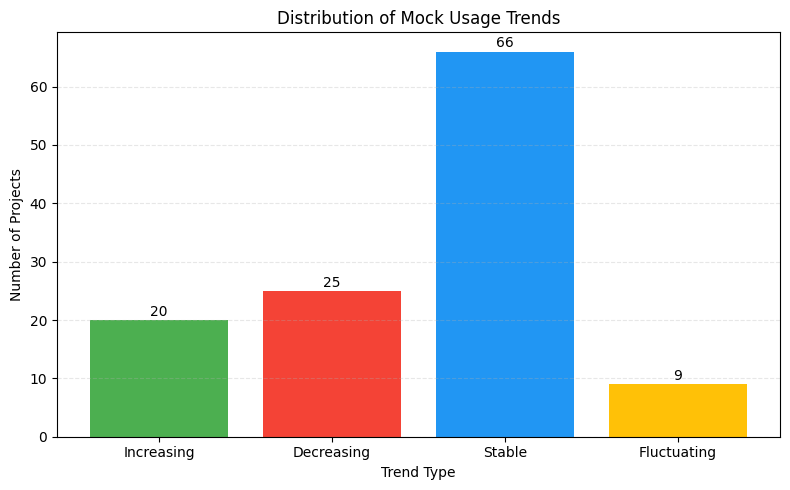

[DONE] Trend distribution plot saved to mock_trend_analysis_trend_distribution.png


In [8]:
import os
import csv
import numpy as np
from sklearn.linear_model import LinearRegression
from collections import Counter

def analyze_mock_trend(base_dir, output_csv):
    """
    Analyze mock usage trends for all projects under output/mock_object_by_year.
    Each project row includes its trend type, yearly percentages, and mock counts.
    """

    projects = []

    for project_name in os.listdir(base_dir):
        project_path = os.path.join(base_dir, project_name)
        if not os.path.isdir(project_path):
            continue

        try:
            data = collect_past_10_years_percentages(project_path)
        except Exception as e:
            print(f"[WARN] Skipping {project_name}: {e}")
            continue

        # Filter out records with percentage == 0
        filtered = [d for d in data if d['percentage'] > 0]
        if not filtered:
            continue

        # Skip if last year's mock count < 50
        # if filtered[-1]['mock_object_count'] < 50:
        #     continue

        # Extract values
        years = [d['year'] for d in filtered]
        percentages = [d['percentage'] for d in filtered]
        mock_counts = [d['mock_object_count'] for d in filtered]

        if len(percentages) < 2:
            continue

        # === Linear Regression on percentage trend ===
        X = np.array(range(len(percentages))).reshape(-1, 1)
        y = np.array(percentages)
        model = LinearRegression().fit(X, y)
        slope = model.coef_[0]

        # Calculate fluctuation (standard deviation of year-to-year changes)
        std_dev = np.std(np.diff(y))

        # === Determine trend ===
        if std_dev > 0.2:
            trend = "Fluctuating"
        elif slope > 0.01:
            trend = "Increasing"
        elif slope < -0.01:
            trend = "Decreasing"
        else:
            trend = "Stable"

        # === Construct CSV row ===
        row = [project_name, trend]
        for p, c in zip(percentages, mock_counts):
            row.append(round(p, 4))
            row.append(c)
        projects.append(row)

    # === Build CSV header ===
    if projects:
        max_years = (max(len(p) for p in projects) - 2) // 2
    else:
        max_years = 0

    headers = ['Project', 'Trend']
    for i in range(1, max_years + 1):
        headers.append(f'Year{i}_Percentage')
        headers.append(f'Year{i}_MockCount')

    # === Write to CSV ===
    with open(output_csv, 'w', newline='', encoding='utf-8-sig') as f:
        writer = csv.writer(f)
        writer.writerow(headers)
        for row in projects:
            writer.writerow(row)

    print(f"[DONE] Analysis completed. {len(projects)} projects written to {output_csv}")

    # === Plot distribution of the 4 trend types ===
    if projects:
        import matplotlib.pyplot as plt

        # Count trends
        trends = [row[1] for row in projects]
        counter = Counter(trends)
        types = ["Increasing", "Decreasing", "Stable", "Fluctuating"]
        counts = [counter.get(t, 0) for t in types]

        # Plot
        plt.figure(figsize=(8, 5))
        bars = plt.bar(types, counts, color=['#4CAF50', '#F44336', '#2196F3', '#FFC107'])
        plt.title("Distribution of Mock Usage Trends")
        plt.xlabel("Trend Type")
        plt.ylabel("Number of Projects")
        plt.grid(axis='y', linestyle='--', alpha=0.3)

        # Annotate bar values
        for bar in bars:
            h = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, h + 0.2, str(int(h)), ha='center', va='bottom')

        # Save and show
        out_img = os.path.splitext(output_csv)[0] + "_trend_distribution.png"
        plt.tight_layout()
        plt.savefig(out_img, dpi=150)
        plt.show()

        print(f"[DONE] Trend distribution plot saved to {out_img}")

# Example usage
if __name__ == "__main__":
    analyze_mock_trend(r'output\\mock_object_by_year', 'mock_trend_analysis.csv')
